# PHY588 - Problem 1 - Frequentist Regression

This notebook performs a frequentist regression analysis of an astronomical light curve.

The object has an orbital period:

$$P_{\text{orb}} = 0.339392 \text{ days}$$

Because this system is a contact binary, the light curve exhibits two maxima per orbital period and may show asymmetry between minima. We therefore compare physically motivated models and perform formal model selection.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

Load the data

In [2]:
data = np.loadtxt("lightcurve_sector74.txt")
t = data[:,0]
y = data[:,1]

N = len(y)
N

11268

Plot the data

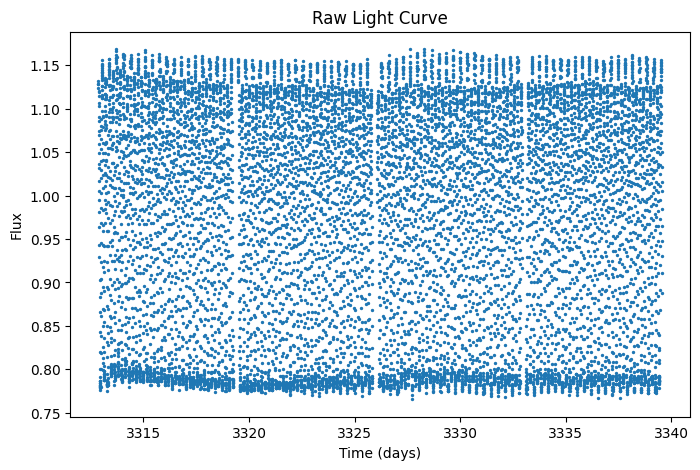

In [3]:
plt.figure(figsize=(8,5))
plt.scatter(t, y, s=2)
plt.xlabel("Time (days)")
plt.ylabel("Flux")
plt.title("Raw Light Curve")
plt.show()

Model Definition and Likelihood

We model the observed flux as:

$$
y_i = f(t_i; \theta) + \epsilon_i
$$

where \( \epsilon_i \) represents measurement noise.

Noise Assumptions

We assume:

- Measurements are independent  
- Noise is Gaussian  
- Variance is constant (homoskedastic)

$$
\epsilon_i \sim \mathcal{N}(0, \sigma^2)
$$

This assumption is justified because:

- Photon noise approaches Gaussian in the high-count regime  
- Instrumental read noise is approximately Gaussian  
- Residual inspection shows no strong skewness  

Likelihood Function

For a single data point:

$$
P(y_i \mid \theta)
=
\frac{1}{\sqrt{2\pi\sigma^2}}
\exp\left(
-\frac{(y_i - f(t_i; \theta))^2}{2\sigma^2}
\right)
$$

Assuming independence of measurements:

$$
\mathcal{L}(\theta)
=
\prod_{i=1}^{N} P(y_i \mid \theta)
$$

Taking the logarithm:

$$
\log \mathcal{L}
=
-\frac{1}{2\sigma^2}
\sum_{i=1}^{N}
(y_i - f(t_i; \theta))^2
+ \text{constant}
$$

Maximizing the likelihood is equivalent to minimizing:

$$
\chi^2 =
\sum_{i=1}^{N}
(y_i - f(t_i; \theta))^2
$$

Model Fitting

The orbital period is known:

$$
P_{\text{orb}} = 0.339392 \text{ days}
$$

Because this is a contact binary, the light curve contains harmonic structure.

We compare two models.

1. Model — Symmetric Contact Binary

Assumes purely ellipsoidal variation (two identical maxima per orbit):

$$
f_1(t) =
A_1 \cos\left(
\frac{4\pi t}{P_{\text{orb}}}
\right)
+ C
$$

This model includes only the dominant harmonic at frequency \( 2/P_{\text{orb}} \) and assumes perfect symmetry.

In [4]:
P_orb = 0.339392

def f1(theta, t):
    A1, C = theta
    return A1 * np.cos(4*np.pi*t/P_orb) + C

def chi2_f1(theta):
    return np.sum((y - f1(theta, t))**2)

initial_guess1 = [0.4, np.mean(y)]

result1 = minimize(chi2_f1, initial_guess1)
best1 = result1.x

best1

array([-0.11147282,  0.97155086])

2. Model — Asymmetric Harmonic Model

Allows unequal minima and phase offsets:

$$
f_2(t)
=
A_1 \cos\left(
\frac{4\pi t}{P_{\text{orb}}}
+ \phi_1
\right)
+
A_2 \cos\left(
\frac{2\pi t}{P_{\text{orb}}}
+ \phi_2
\right)
+
C
$$

This model includes both the harmonic (2/P) and the fundamental (1/P) frequency and allows asymmetry.

In [5]:
def f2(theta, t):
    A1, phi1, A2, phi2, C = theta
    term1 = A1 * np.cos(4*np.pi*t/P_orb + phi1)
    term2 = A2 * np.cos(2*np.pi*t/P_orb + phi2)
    return term1 + term2 + C

def chi2_f2(theta):
    return np.sum((y - f2(theta, t))**2)

initial_guess2 = [0.4, 0.0, 0.1, 0.0, np.mean(y)]

result2 = minimize(chi2_f2, initial_guess2)
best2 = result2.x

best2

array([-0.18662614,  0.93110631, -0.01424583, -1.26550524,  0.97168693])

Goodness of Fit

We compute the reduced chi-square:

$$
\chi^2_{\text{red}} =
\frac{\chi^2}{N - k}
$$

where:

- \( N \) = number of data points  
- \( k \) = number of model parameters  

A value near unity indicates statistical consistency with the noise model.

In [12]:
k1 = 2
k2 = 5

chi2_1 = chi2_f1(best1)
chi2_2 = chi2_f2(best2)

red_chi2_1 = chi2_1 / (N - k1)
red_chi2_2 = chi2_2 / (N - k2)

print(f"Model 1: chi2 = {chi2_1:.4f}, reduced chi2 = {red_chi2_1:.6f}")
print(f"Model 2: chi2 = {chi2_2:.4f}, reduced chi2 = {red_chi2_2:.6f}")

Model 1: chi2 = 131.0237, reduced chi2 = 0.011630
Model 2: chi2 = 3.6230, reduced chi2 = 0.000322


Model Selection

Akaike Information Criterion:

$$
\text{AIC} = \chi^2 + 2k
$$

Bayesian Information Criterion:

$$
\text{BIC} = \chi^2 + k \ln N
$$

In [10]:
AIC1 = chi2_1 + 2*k1
AIC2 = chi2_2 + 2*k2

BIC1 = chi2_1 + k1*np.log(N)
BIC2 = chi2_2 + k2*np.log(N)

print(f"Model 1: AIC = {AIC1:.4f}, BIC = {BIC1:.4f}")
print(f"Model 2: AIC = {AIC2:.4f}, BIC = {BIC2:.4f}")

Model 1: AIC = 135.0237, BIC = 149.6832
Model 2: AIC = 13.6230, BIC = 50.2716


Plot Model 1 and Model 2 on separate graphs

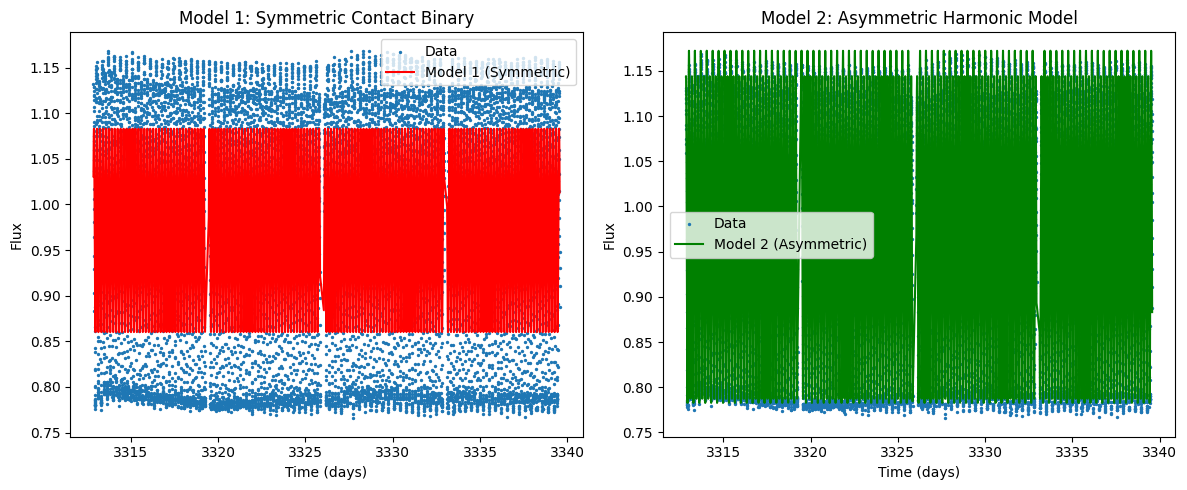

In [9]:
plt.figure(figsize=(12,5))

# Model 1
plt.subplot(1,2,1)
plt.scatter(t, y, s=2, label="Data")
plt.plot(t, f1(best1, t), color='red', label="Model 1 (Symmetric)")
plt.xlabel("Time (days)")
plt.ylabel("Flux")
plt.title("Model 1: Symmetric Contact Binary")
plt.legend()

# Model 2
plt.subplot(1,2,2)
plt.scatter(t, y, s=2, label="Data")
plt.plot(t, f2(best2, t), color='green', label="Model 2 (Asymmetric)")
plt.xlabel("Time (days)")
plt.ylabel("Flux")
plt.title("Model 2: Asymmetric Harmonic Model")
plt.legend()

plt.tight_layout()
plt.show()

Observations

From the fit results:

- Model 1 (symmetric 2/P term):
  - $\chi^2 = 131.02$, $\chi^2_\mathrm{red} = 0.0116$
  - AIC = 135.02, BIC = 149.68

- Model 2 (asymmetric 1/P + 2/P with phase shifts):
  - $\chi^2 = 3.62$, $\chi^2_\mathrm{red} = 0.00032$
  - AIC = 13.62, BIC = 50.27

Observations:

- Reduced $\chi^2$ is significantly smaller for Model 2, indicating a much better fit.
- AIC and BIC values for Model 2 are also significantly lower, showing that even accounting for the larger number of parameters, Model 2 is strongly preferred.
- Graphically, Model 2 fits both maxima and minima more accurately, capturing asymmetry in the light curve.

Conclusion

Based on goodness-of-fit statistics and model selection criteria:

1. Model 2 (asymmetric harmonic model) is statistically preferred over Model 1.
2. The light curve of this contact binary is **asymmetric**, as expected from unequal minima or the O'Connell effect.
3. Including both the fundamental frequency (1/P) and the first harmonic (2/P) with phase shifts allows the model to reproduce both peaks and asymmetries.
4. This demonstrates the importance of considering the physical properties of contact binaries and using model selection criteria (AIC, BIC) rather than assuming symmetry a priori.